Observed peak: 18:00 UTC
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/mean_diurnal_swdown_cid1.png


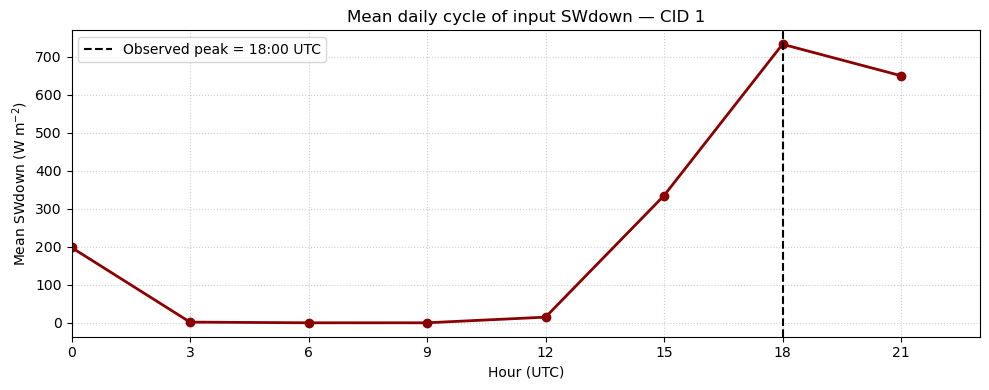

In [3]:
import os
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd


EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yr_4hru_full_domain_no_downscale"
CID = 1
OUT = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/mean_diurnal_swdown_cid1.png"

ncpath = os.path.join(EDIR, str(CID), "input_file.nc")

# Read time and SWdown.
with nc.Dataset(ncpath) as dataset:
    met = dataset.groups["meteorology"]
    time = met.variables["time"]
    dates = nc.num2date(time[:], units=time.units, calendar=getattr(time, "calendar", "standard"), only_use_cftime_datetimes=False, only_use_python_datetimes=True) #cft means climate and forcast time
    swdown = met.variables["swdown"][:].filled(np.nan)

dates = pd.DatetimeIndex(dates)

# Ensure array order is (time, HRU).
if swdown.ndim == 2 and swdown.shape[0] != len(dates):
    swdown = swdown.T

# Average the HRUs.
if swdown.ndim == 2:
    swdown = np.nanmean(swdown, axis=1)

# Calculate the mean daily cycle.
series = pd.Series(swdown, index=dates)
mean_daily_cycle = series.groupby(series.index.hour).mean()
peak_hour = int(mean_daily_cycle.idxmax())

# Plot.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_daily_cycle.index, mean_daily_cycle.values, color="darkred", marker="o", linewidth=2)
ax.axvline(peak_hour, color="black", linestyle="--", label=f"Observed peak = {peak_hour:02d}:00 UTC")

ax.set_xticks(np.arange(0, 24, 3))
ax.set_xlim(0, 23)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"Mean SWdown (W m$^{-2}$)")
ax.set_title(f"Mean daily cycle of input SWdown — CID {CID}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

fig.tight_layout()

# Save and show.
os.makedirs(os.path.dirname(OUT), exist_ok=True)
fig.savefig(OUT, dpi=300, bbox_inches="tight")

print(f"Observed peak: {peak_hour:02d}:00 UTC")
print(f"Saved: {OUT}")

plt.show()

In [4]:
with nc.Dataset(ncpath) as dataset:
    met = dataset.groups["meteorology"]
    time = met.variables["time"]

    print("Time units:", time.units)
    print("Calendar:", getattr(time, "calendar", "standard"))
    print("Timezone:", getattr(time, "timezone", "not specified"))

Time units: hours since 2014-01-01
Calendar: standard
Timezone: not specified


In [2]:
import earthaccess
import xarray as xr
import os

earthaccess.login()

LAT_MIN, LAT_MAX = 34.03055, 34.17283
LON_MIN, LON_MAX = -113.89591, -113.85827

START, END = "2014-07-01", "2014-07-31"  # start with one month to test

OUT_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"
os.makedirs(OUT_DIR, exist_ok=True)

results = earthaccess.search_data(
    short_name="NLDAS_FORA0125_H",
    version="2.0",
    temporal=(START, END),
    bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
)

print(f"Found {len(results)} granules")

files = earthaccess.download(results, local_path=OUT_DIR)

print(f"Downloaded {len(files)} files to {OUT_DIR}")

/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


Found 744 granules


QUEUEING TASKS | : 100%|██████████| 744/744 [00:00<00:00, 50470.03it/s]
PROCESSING TASKS | : 100%|██████████| 744/744 [01:00<00:00, 12.35it/s]
COLLECTING RESULTS | : 100%|██████████| 744/744 [00:00<00:00, 888795.83it/s]

Downloaded 744 files to /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare


In [3]:
import os
files = sorted(os.listdir(OUT_DIR))
print(len(files))
print(files[:5])

744
['NLDAS_FORA0125_H.A20140701.0000.020.nc', 'NLDAS_FORA0125_H.A20140701.0100.020.nc', 'NLDAS_FORA0125_H.A20140701.0200.020.nc', 'NLDAS_FORA0125_H.A20140701.0300.020.nc', 'NLDAS_FORA0125_H.A20140701.0400.020.nc']


In [4]:
import xarray as xr

sample = os.path.join(OUT_DIR, files[0])
ds = xr.open_dataset(sample)
print(ds)

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 1, bnds: 2, lat: 224, lon: 464)
Coordinates:
  * time         (time) datetime64[ns] 8B 2014-07-01
  * lat          (lat) float32 896B 25.06 25.19 25.31 ... 52.69 52.81 52.94
  * lon          (lon) float32 2kB -124.9 -124.8 -124.7 ... -67.31 -67.19 -67.06
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (time, bnds) datetime64[ns] 16B ...
    Tair         (time, lat, lon) float32 416kB ...
    Qair         (time, lat, lon) float32 416kB ...
    PSurf        (time, lat, lon) float32 416kB ...
    Wind_E       (time, lat, lon) float32 416kB ...
    Wind_N       (time, lat, lon) float32 416kB ...
    LWdown       (time, lat, lon) float32 416kB ...
    CRainf_frac  (time, lat, lon) float32 416kB ...
    CAPE         (time, lat, lon) float32 416kB ...
    PotEvap      (time, lat, lon) float32 416kB ...
    Rainf        (time, lat, lon) float32 416kB ...
    SWdown       (time, lat, lon) float32 416kB ...
Attributes: (12/

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- Pick the day ----
DAY = "2014-07-15"  # change to whichever day you want

# ---- NLDAS: hourly values for that day ----
swdown_nldas_day = swdown_nldas.to_series().loc[DAY]  # from previous cell, already lat/lon-averaged

# ---- MSWX / HydroBlocks input: values for that day ----
series_mswx = pd.Series(swdown, index=dates)  # from your original input_file.nc read
swdown_mswx_day = series_mswx.loc[DAY]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(swdown_mswx_day.index, swdown_mswx_day.values,
        color="darkred", marker="o", linewidth=2, label="MSWX (HydroBlocks input)")
ax.plot(swdown_nldas_day.index, swdown_nldas_day.values,
        color="steelblue", marker="s", linewidth=2, label="NLDAS-2")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"SWdown (W m$^{-2}$)")
ax.set_title(f"SWdown — MSWX vs NLDAS-2 — CID 1, {DAY}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.autofmt_xdate()

fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_mswx_vs_nldas_cid1_{DAY}.png"
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

NameError: name 'swdown_nldas' is not defined

In [7]:
import netCDF4 as nc

output_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale/output_data/1/2014-01-01.nc"

def dump(group, indent=0):
    pad = "  " * indent
    print(f"{pad}Variables:")
    for name, var in group.variables.items():
        print(f"{pad}  {name}: dims={var.dimensions}, shape={var.shape}, dtype={var.dtype}")
    for subname, subgrp in group.groups.items():
        print(f"{pad}Group: {subname}")
        dump(subgrp, indent + 1)

with nc.Dataset(output_path) as dataset:
    print(f"File: {output_path}\n")
    print("Top-level groups:", list(dataset.groups.keys()))
    print("Top-level dimensions:", {k: len(v) for k, v in dataset.dimensions.items()})
    dump(dataset)

File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale/output_data/1/2014-01-01.nc

Top-level groups: ['data', 'metadata']
Top-level dimensions: {'hru': 100, 'time': 32120, 'soil': 10, 'snow': 3, 'hband': 10}
Variables:
Group: data
  Variables:
    qsnow: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    totsmc: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    swe: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    snow_t: dims=('time', 'hru', 'snow'), shape=(32120, 100, 3), dtype=float32
    snowh: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    fsno: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    t2mv: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    t2mb: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    swdn: dims=('time', 'hru'), shape=(32120, 100), dtype=float32
    swnet: dims=('time', 'hr

In [3]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    time_var = meta.variables["time"]
    date_var = meta.variables["date"]

    print("=== time variable ===")
    print("dtype:", time_var.dtype)
    print("attributes:", time_var.ncattrs())
    for attr in time_var.ncattrs():
        print(f"  {attr}: {getattr(time_var, attr)}")
    print("first 5 values:", time_var[:5])
    print("last 5 values:", time_var[-5:])

    print("\n=== date variable ===")
    print("dtype:", date_var.dtype)
    print("attributes:", date_var.ncattrs())
    for attr in date_var.ncattrs():
        print(f"  {attr}: {getattr(date_var, attr)}")
    print("first 5 values:", date_var[:5])
    print("last 5 values:", date_var[-5:])

=== time variable ===
dtype: float64
attributes: []
first 5 values: [-- -- -- -- --]
last 5 values: [-- -- -- -- --]

=== date variable ===
dtype: float64
attributes: ['units', 'calendar']
  units: hours since 1900-01-01
  calendar: standard
first 5 values: [999312. 999315. 999318. 999321. 999324.]
last 5 values: [1095657. 1095660. 1095663. 1095666. 1095669.]


Model output time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
NLDAS nearest grid cell: lat=34.0625, lon=-113.9375
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_cid1_2014-07-15.png


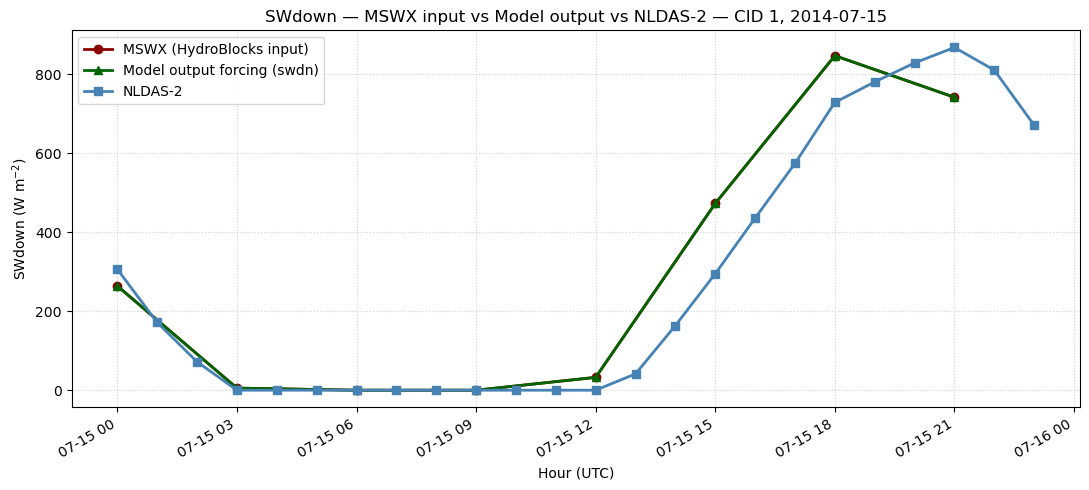

In [5]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Paths
# ============================================================
EDIR_11YR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale"
CID = 1

input_path  = os.path.join(EDIR_11YR, str(CID), "input_file.nc")
output_path = os.path.join(EDIR_11YR, "output_data", str(CID), "2014-01-01.nc")

NLDAS_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"

DAY = "2014-07-15"

# ============================================================
# 1. MSWX forcing input (3-hourly) — HRU-averaged
# ============================================================
with nc.Dataset(input_path) as ds:
    met = ds.groups["meteorology"]
    time_var = met.variables["time"]
    input_dates = nc.num2date(time_var[:], units=time_var.units,
                               calendar=getattr(time_var, "calendar", "standard"),
                               only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    input_dates = pd.DatetimeIndex(input_dates)
    swdown_in = met.variables["swdown"][:].filled(np.nan)

    lats = np.array(ds.groups["parameters"].variables["lats"][:])
    lons = np.array(ds.groups["parameters"].variables["lons"][:])

if swdown_in.ndim == 2 and swdown_in.shape[0] != len(input_dates):
    swdown_in = swdown_in.T

swdown_in_mean = np.nanmean(swdown_in, axis=1)
series_mswx = pd.Series(swdown_in_mean, index=input_dates)

# ============================================================
# 2. Model output forcing (swdn) — HRU-averaged, using 'date' variable
# ============================================================
with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    date_var = meta.variables["date"]
    output_dates = nc.num2date(date_var[:], units=date_var.units,
                                calendar=getattr(date_var, "calendar", "standard"),
                                only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    output_dates = pd.DatetimeIndex(output_dates)

    swdn_out = ds.groups["data"].variables["swdn"][:]  # (time, hru)

swdn_out_mean = np.nanmean(swdn_out, axis=1)
series_output = pd.Series(swdn_out_mean, index=output_dates)

print(f"Model output time range: {output_dates.min()} to {output_dates.max()}")

# ============================================================
# 3. NLDAS (hourly) — nearest grid cell to domain center
# ============================================================
ds_all = xr.open_mfdataset(os.path.join(NLDAS_DIR, "*.nc"), combine="by_coords")

center_lat = (lats.min() + lats.max()) / 2
center_lon = (lons.min() + lons.max()) / 2

ds_nearest = ds_all.sel(lat=center_lat, lon=center_lon, method="nearest")
print(f"NLDAS nearest grid cell: lat={float(ds_nearest.lat):.4f}, lon={float(ds_nearest.lon):.4f}")

swdown_nldas_da = ds_nearest["SWdown"].load()
series_nldas = swdown_nldas_da.to_series()

# ============================================================
# 4. Restrict all three to the chosen day and plot
# ============================================================
mswx_day   = series_mswx.loc[DAY]
output_day = series_output.loc[DAY]
nldas_day  = series_nldas.loc[DAY]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(mswx_day.index, mswx_day.values, color="darkred", marker="o",
        linewidth=2, label="MSWX (HydroBlocks input)")

ax.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
        linewidth=2, label="Model output forcing (swdn)")

ax.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
        linewidth=2, label="NLDAS-2")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"SWdown (W m$^{-2}$)")
ax.set_title(f"SWdown — MSWX input vs Model output vs NLDAS-2 — CID {CID}, {DAY}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_cid{CID}_{DAY}.png"
os.makedirs(os.path.dirname(out_plot), exist_ok=True)
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

In [6]:
import netCDF4 as nc

swdown_raw_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/swdown.nc"

with nc.Dataset(swdown_raw_path) as ds:
    print("Dimensions:", {k: len(v) for k, v in ds.dimensions.items()})
    print("Variables:")
    for name, var in ds.variables.items():
        print(f"  {name}: dims={var.dimensions}, shape={var.shape}")
        for attr in var.ncattrs():
            print(f"    {attr} = {getattr(var, attr)}")

Dimensions: {'lon': 8, 'lat': 8, 't': 32120}
Variables:
  lon: dims=('lon',), shape=(8,)
    units = degrees_east
    long_name = Longitude
    res = 0.10000228881835938
  lat: dims=('lat',), shape=(8,)
    units = degrees_north
    long_name = Latitude
    res = 0.10000228881835938
  t: dims=('t',), shape=(32120,)
    units = 3hr since 2014-01-01 00:00:00.0
    long_name = Time
  swdown: dims=('t', 'lat', 'lon'), shape=(32120, 8, 8)
    _FillValue = -9999.0
    long_name = swdown


Model output time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
NLDAS nearest grid cell: lat=34.0625, lon=-113.9375
Raw MSWX source time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_4way_cid1_2014-07-15.png


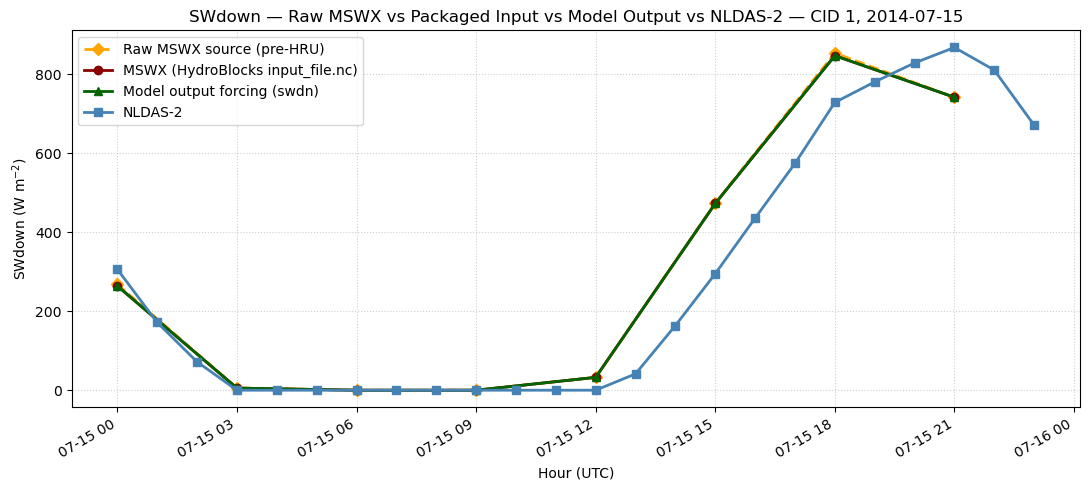

In [7]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Paths
# ============================================================
EDIR_11YR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale"
CID = 1

input_path      = os.path.join(EDIR_11YR, str(CID), "input_file.nc")
output_path     = os.path.join(EDIR_11YR, "output_data", str(CID), "2014-01-01.nc")
swdown_raw_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/swdown.nc"

NLDAS_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"

DAY = "2014-07-15"

# ============================================================
# 1. MSWX packaged input (input_file.nc, 3-hourly) — HRU-averaged
# ============================================================
with nc.Dataset(input_path) as ds:
    met = ds.groups["meteorology"]
    time_var = met.variables["time"]
    input_dates = nc.num2date(time_var[:], units=time_var.units,
                               calendar=getattr(time_var, "calendar", "standard"),
                               only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    input_dates = pd.DatetimeIndex(input_dates)
    swdown_in = met.variables["swdown"][:].filled(np.nan)

    lats = np.array(ds.groups["parameters"].variables["lats"][:])
    lons = np.array(ds.groups["parameters"].variables["lons"][:])

if swdown_in.ndim == 2 and swdown_in.shape[0] != len(input_dates):
    swdown_in = swdown_in.T

swdown_in_mean = np.nanmean(swdown_in, axis=1)
series_mswx = pd.Series(swdown_in_mean, index=input_dates)

# ============================================================
# 2. Model output forcing (swdn) — HRU-averaged, using 'date' variable
# ============================================================
with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    date_var = meta.variables["date"]
    output_dates = nc.num2date(date_var[:], units=date_var.units,
                                calendar=getattr(date_var, "calendar", "standard"),
                                only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    output_dates = pd.DatetimeIndex(output_dates)

    swdn_out = ds.groups["data"].variables["swdn"][:]  # (time, hru)

swdn_out_mean = np.nanmean(swdn_out, axis=1)
series_output = pd.Series(swdn_out_mean, index=output_dates)

print(f"Model output time range: {output_dates.min()} to {output_dates.max()}")

# ============================================================
# 3. NLDAS (hourly) — nearest grid cell to domain center
# ============================================================
ds_all = xr.open_mfdataset(os.path.join(NLDAS_DIR, "*.nc"), combine="by_coords")

center_lat = (lats.min() + lats.max()) / 2
center_lon = (lons.min() + lons.max()) / 2

ds_nearest = ds_all.sel(lat=center_lat, lon=center_lon, method="nearest")
print(f"NLDAS nearest grid cell: lat={float(ds_nearest.lat):.4f}, lon={float(ds_nearest.lon):.4f}")

swdown_nldas_da = ds_nearest["SWdown"].load()
series_nldas = swdown_nldas_da.to_series()

# ============================================================
# 4. Raw MSWX gridded source (swdown.nc) — spatial mean over CID 1's grid cells
# ============================================================
with nc.Dataset(swdown_raw_path) as ds:
    t_var = ds.variables["t"]
    # units = "3hr since 2014-01-01 00:00:00.0" -- custom parsing
    raw_dates = pd.date_range("2014-01-01 00:00:00", periods=len(t_var), freq="3h")

    swdown_raw = ds.variables["swdown"][:]  # (t, lat, lon)
    swdown_raw = np.ma.filled(swdown_raw, np.nan)

swdown_raw_mean = np.nanmean(swdown_raw, axis=(1, 2))
series_raw_mswx = pd.Series(swdown_raw_mean, index=raw_dates)

print(f"Raw MSWX source time range: {raw_dates.min()} to {raw_dates.max()}")

# ============================================================
# 5. Restrict all four to the chosen day
# ============================================================
mswx_day     = series_mswx.loc[DAY]
output_day   = series_output.loc[DAY]
nldas_day    = series_nldas.loc[DAY]
raw_mswx_day = series_raw_mswx.loc[DAY]

# ============================================================
# 6. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(raw_mswx_day.index, raw_mswx_day.values, color="orange", marker="D",
        linewidth=2, linestyle="--", label="Raw MSWX source (pre-HRU)")

ax.plot(mswx_day.index, mswx_day.values, color="darkred", marker="o",
        linewidth=2, label="MSWX (HydroBlocks input_file.nc)")

ax.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
        linewidth=2, label="Model output forcing (swdn)")

ax.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
        linewidth=2, label="NLDAS-2")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"SWdown (W m$^{-2}$)")
ax.set_title(f"SWdown — Raw MSWX vs Packaged Input vs Model Output vs NLDAS-2 — CID {CID}, {DAY}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_4way_cid{CID}_{DAY}.png"
os.makedirs(os.path.dirname(out_plot), exist_ok=True)
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

Model output time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
Raw MSWX source time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
NLDAS nearest grid cell: lat=34.1875, lon=-113.8125
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_raw_cid1_2014-07-15.png


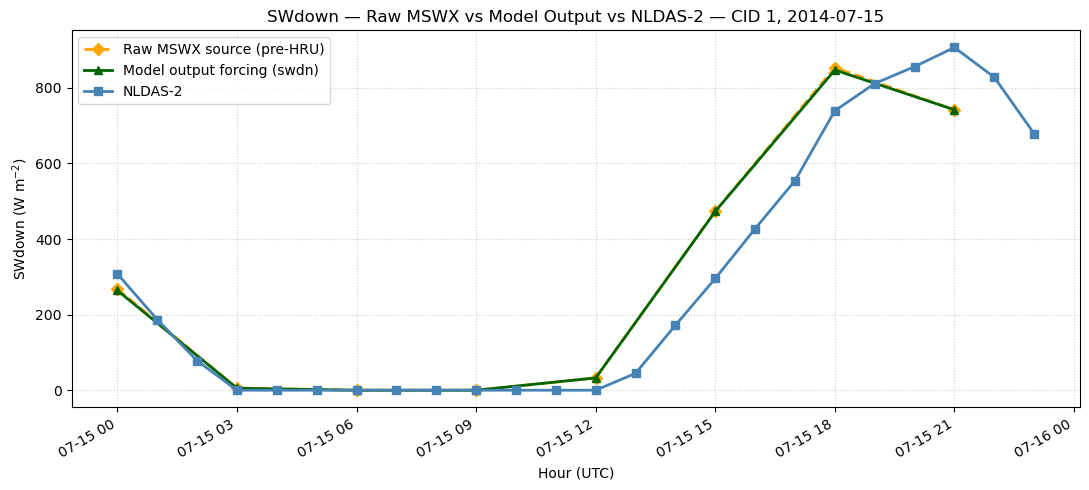

In [8]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Paths
# ============================================================
EDIR_11YR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale"
CID = 1

output_path     = os.path.join(EDIR_11YR, "output_data", str(CID), "2014-01-01.nc")
swdown_raw_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/swdown.nc"

NLDAS_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"

DAY = "2014-07-15"

# ============================================================
# 1. Model output forcing (swdn) — HRU-averaged, using 'date' variable
# ============================================================
with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    date_var = meta.variables["date"]
    output_dates = nc.num2date(date_var[:], units=date_var.units,
                                calendar=getattr(date_var, "calendar", "standard"),
                                only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    output_dates = pd.DatetimeIndex(output_dates)

    swdn_out = ds.groups["data"].variables["swdn"][:]  # (time, hru)

swdn_out_mean = np.nanmean(swdn_out, axis=1)
series_output = pd.Series(swdn_out_mean, index=output_dates)

print(f"Model output time range: {output_dates.min()} to {output_dates.max()}")

# ============================================================
# 2. Raw MSWX gridded source (swdown.nc) — spatial mean over CID 1's grid cells
# ============================================================
with nc.Dataset(swdown_raw_path) as ds:
    t_var = ds.variables["t"]
    raw_dates = pd.date_range("2014-01-01 00:00:00", periods=len(t_var), freq="3h")

    swdown_raw = ds.variables["swdown"][:]  # (t, lat, lon)
    swdown_raw = np.ma.filled(swdown_raw, np.nan)

    lats = np.array(ds.variables["lat"][:])
    lons = np.array(ds.variables["lon"][:])

swdown_raw_mean = np.nanmean(swdown_raw, axis=(1, 2))
series_raw_mswx = pd.Series(swdown_raw_mean, index=raw_dates)

print(f"Raw MSWX source time range: {raw_dates.min()} to {raw_dates.max()}")

# ============================================================
# 3. NLDAS (hourly) — nearest grid cell to domain center
# ============================================================
ds_all = xr.open_mfdataset(os.path.join(NLDAS_DIR, "*.nc"), combine="by_coords")

center_lat = (lats.min() + lats.max()) / 2
center_lon = (lons.min() + lons.max()) / 2

ds_nearest = ds_all.sel(lat=center_lat, lon=center_lon, method="nearest")
print(f"NLDAS nearest grid cell: lat={float(ds_nearest.lat):.4f}, lon={float(ds_nearest.lon):.4f}")

swdown_nldas_da = ds_nearest["SWdown"].load()
series_nldas = swdown_nldas_da.to_series()

# ============================================================
# 4. Restrict to the chosen day
# ============================================================
output_day   = series_output.loc[DAY]
nldas_day    = series_nldas.loc[DAY]
raw_mswx_day = series_raw_mswx.loc[DAY]

# ============================================================
# 5. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(raw_mswx_day.index, raw_mswx_day.values, color="orange", marker="D",
        linewidth=2, linestyle="--", label="Raw MSWX source (pre-HRU)")

ax.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
        linewidth=2, label="Model output forcing (swdn)")

ax.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
        linewidth=2, label="NLDAS-2")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"SWdown (W m$^{-2}$)")
ax.set_title(f"SWdown — Raw MSWX vs Model Output vs NLDAS-2 — CID {CID}, {DAY}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_raw_cid{CID}_{DAY}.png"
os.makedirs(os.path.dirname(out_plot), exist_ok=True)
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

In [9]:
print("=== Raw MSWX grid ===")
print(f"lat range: {lats.min():.4f} to {lats.max():.4f}")
print(f"lon range: {lons.min():.4f} to {lons.max():.4f}")
print(f"lat values: {lats}")
print(f"lon values: {lons}")

print("\n=== NLDAS selected cell ===")
print(f"lat: {float(ds_nearest.lat):.4f}")
print(f"lon: {float(ds_nearest.lon):.4f}")

print("\n=== Your CID 1 HRU domain (from input_file.nc, if still in memory) ===")
# lat: 34.03055 to 34.17283
# lon: -113.89591 to -113.85827

=== Raw MSWX grid ===
lat range: 33.8000 to 34.5000
lon range: -114.2000 to -113.5000
lat values: [33.80000114 33.90000343 34.00000572 34.10000801 34.2000103  34.30001259
 34.40001488 34.50001717]
lon values: [-114.19999123 -114.09998894 -113.99998665 -113.89998436 -113.79998207
 -113.69997978 -113.59997749 -113.4999752 ]

=== NLDAS selected cell ===
lat: 34.1875
lon: -113.8125

=== Your CID 1 HRU domain (from input_file.nc, if still in memory) ===


Model output time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
MSWX lat cells within CID 1: [34.10000801]
MSWX lon cells within CID 1: []
No exact overlap -- used nearest MSWX cell: lat=34.1000, lon=-113.9000
Raw MSWX source time range: 2014-01-01 00:00:00 to 2024-12-28 21:00:00
NLDAS nearest grid cell: lat=34.0625, lon=-113.9375
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_raw_cid1_2014-07-15.png


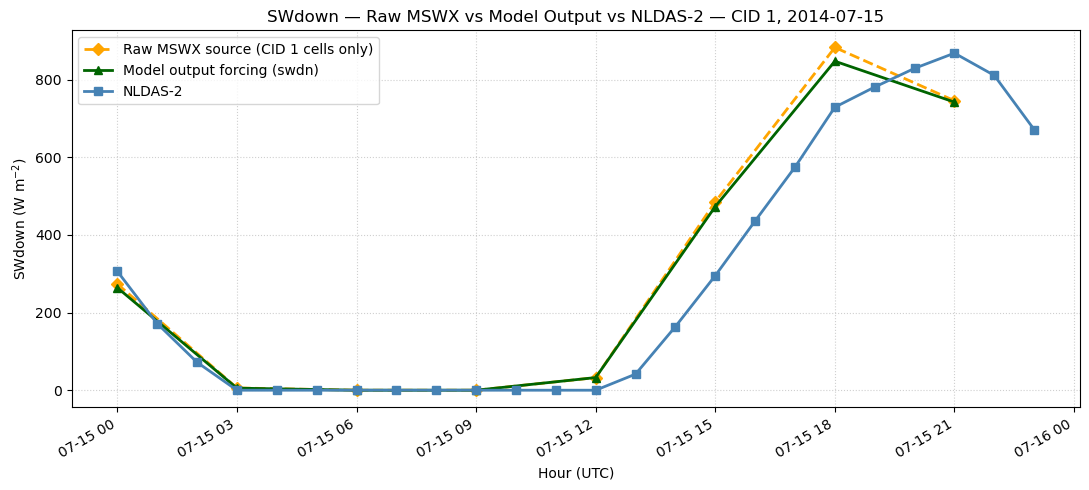

In [10]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Paths
# ============================================================
EDIR_11YR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale"
CID = 1

output_path     = os.path.join(EDIR_11YR, "output_data", str(CID), "2014-01-01.nc")
swdown_raw_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/swdown.nc"

NLDAS_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"

DAY = "2014-07-15"

# CID 1's actual HRU bounding box (from input_file.nc parameters/lats,lons)
CID1_LAT_MIN, CID1_LAT_MAX = 34.03055, 34.17283
CID1_LON_MIN, CID1_LON_MAX = -113.89591, -113.85827

# ============================================================
# 1. Model output forcing (swdn) — HRU-averaged, using 'date' variable
# ============================================================
with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    date_var = meta.variables["date"]
    output_dates = nc.num2date(date_var[:], units=date_var.units,
                                calendar=getattr(date_var, "calendar", "standard"),
                                only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    output_dates = pd.DatetimeIndex(output_dates)

    swdn_out = ds.groups["data"].variables["swdn"][:]  # (time, hru)

swdn_out_mean = np.nanmean(swdn_out, axis=1)
series_output = pd.Series(swdn_out_mean, index=output_dates)

print(f"Model output time range: {output_dates.min()} to {output_dates.max()}")

# ============================================================
# 2. Raw MSWX gridded source (swdown.nc, 0.1 deg) — subset to CID 1's domain only
# ============================================================
with nc.Dataset(swdown_raw_path) as ds:
    t_var = ds.variables["t"]
    raw_dates = pd.date_range("2014-01-01 00:00:00", periods=len(t_var), freq="3h")

    swdown_raw = ds.variables["swdown"][:]  # (t, lat, lon)
    swdown_raw = np.ma.filled(swdown_raw, np.nan)

    lats = np.array(ds.variables["lat"][:])
    lons = np.array(ds.variables["lon"][:])

lat_mask = (lats >= CID1_LAT_MIN) & (lats <= CID1_LAT_MAX)
lon_mask = (lons >= CID1_LON_MIN) & (lons <= CID1_LON_MAX)

print("MSWX lat cells within CID 1:", lats[lat_mask])
print("MSWX lon cells within CID 1:", lons[lon_mask])

if lat_mask.sum() == 0 or lon_mask.sum() == 0:
    # Fallback: nearest single grid cell to CID 1's centroid
    center_lat = (CID1_LAT_MIN + CID1_LAT_MAX) / 2
    center_lon = (CID1_LON_MIN + CID1_LON_MAX) / 2
    lat_idx = np.abs(lats - center_lat).argmin()
    lon_idx = np.abs(lons - center_lon).argmin()
    swdown_raw_mean = swdown_raw[:, lat_idx, lon_idx]
    print(f"No exact overlap -- used nearest MSWX cell: lat={lats[lat_idx]:.4f}, lon={lons[lon_idx]:.4f}")
else:
    swdown_raw_subset = swdown_raw[:, lat_mask, :][:, :, lon_mask]
    swdown_raw_mean = np.nanmean(swdown_raw_subset, axis=(1, 2))

series_raw_mswx = pd.Series(swdown_raw_mean, index=raw_dates)

print(f"Raw MSWX source time range: {raw_dates.min()} to {raw_dates.max()}")

# ============================================================
# 3. NLDAS (hourly) — nearest grid cell to CID 1's centroid
# ============================================================
ds_all = xr.open_mfdataset(os.path.join(NLDAS_DIR, "*.nc"), combine="by_coords")

center_lat = (CID1_LAT_MIN + CID1_LAT_MAX) / 2
center_lon = (CID1_LON_MIN + CID1_LON_MAX) / 2

ds_nearest = ds_all.sel(lat=center_lat, lon=center_lon, method="nearest")
print(f"NLDAS nearest grid cell: lat={float(ds_nearest.lat):.4f}, lon={float(ds_nearest.lon):.4f}")

swdown_nldas_da = ds_nearest["SWdown"].load()
series_nldas = swdown_nldas_da.to_series()

# ============================================================
# 4. Restrict to the chosen day
# ============================================================
output_day   = series_output.loc[DAY]
nldas_day    = series_nldas.loc[DAY]
raw_mswx_day = series_raw_mswx.loc[DAY]

# ============================================================
# 5. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(raw_mswx_day.index, raw_mswx_day.values, color="orange", marker="D",
        linewidth=2, linestyle="--", label="Raw MSWX source (CID 1 cells only)")

ax.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
        linewidth=2, label="Model output forcing (swdn)")

ax.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
        linewidth=2, label="NLDAS-2")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel(r"SWdown (W m$^{-2}$)")
ax.set_title(f"SWdown — Raw MSWX vs Model Output vs NLDAS-2 — CID {CID}, {DAY}")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_3way_raw_cid{CID}_{DAY}.png"
os.makedirs(os.path.dirname(out_plot), exist_ok=True)
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

True solar noon (max elevation) on 2014-07-15: 2014-07-15 19:40:00
Max solar elevation: 77.43 degrees
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/solar_noon_check_cid1_2014-07-15.png


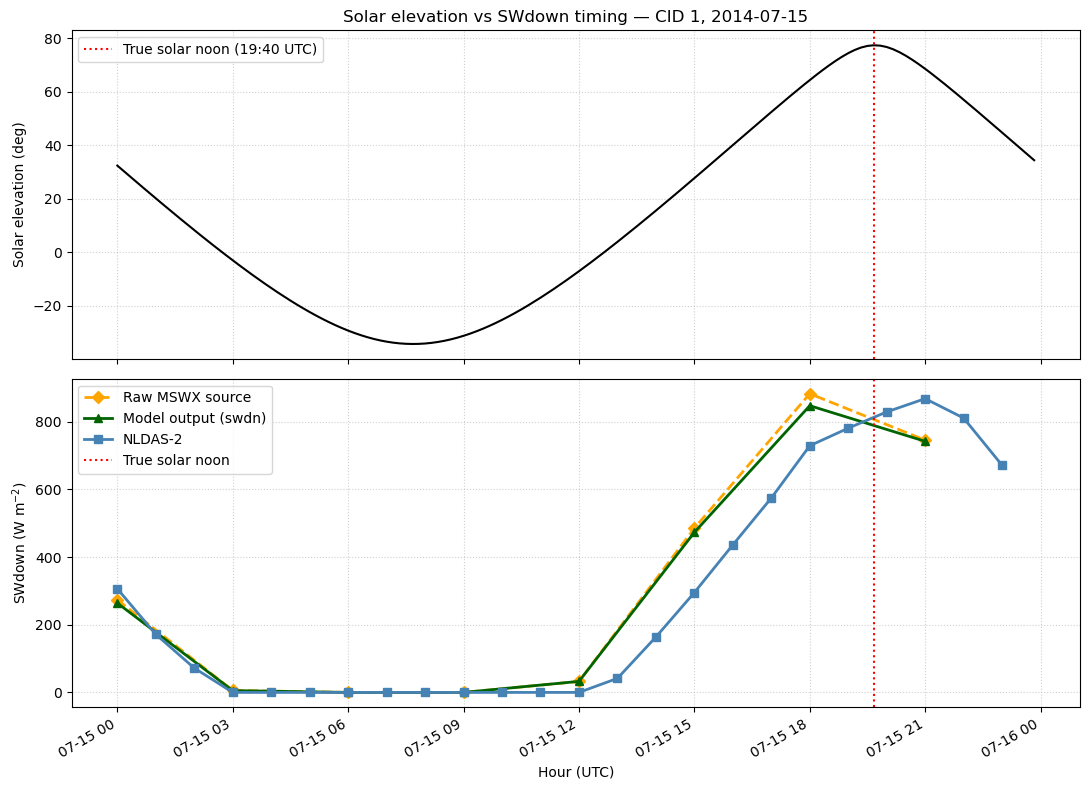

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Solar position calculation (no external astronomy library needed)
# ============================================================
LAT = 34.10   # CID 1 domain center
LON = -113.88

def solar_elevation(dt_utc, lat, lon):
    """Compute solar elevation angle (degrees) for given UTC datetime and location."""
    n = dt_utc.dayofyear + (dt_utc.hour + dt_utc.minute/60 + dt_utc.second/3600) / 24.0

    # Fractional year (radians)
    gamma = 2 * np.pi / 365 * (n - 1)

    # Equation of time (minutes)
    eqtime = 229.18 * (0.000075 + 0.001868*np.cos(gamma) - 0.032077*np.sin(gamma)
                        - 0.014615*np.cos(2*gamma) - 0.040849*np.sin(2*gamma))

    # Solar declination (radians)
    decl = (0.006918 - 0.399912*np.cos(gamma) + 0.070257*np.sin(gamma)
            - 0.006758*np.cos(2*gamma) + 0.000907*np.sin(2*gamma)
            - 0.002697*np.cos(3*gamma) + 0.00148*np.sin(3*gamma))

    time_offset = eqtime + 4 * lon  # minutes
    tst = (dt_utc.hour*60 + dt_utc.minute + dt_utc.second/60) + time_offset  # true solar time, minutes
    ha = (tst / 4) - 180  # hour angle, degrees

    lat_rad = np.radians(lat)
    ha_rad = np.radians(ha)

    cos_zenith = (np.sin(lat_rad)*np.sin(decl) +
                  np.cos(lat_rad)*np.cos(decl)*np.cos(ha_rad))
    elevation = 90 - np.degrees(np.arccos(np.clip(cos_zenith, -1, 1)))
    return elevation

# ============================================================
# Compute solar elevation across the day at fine (10-min) resolution
# ============================================================
DAY = "2014-07-15"
fine_times = pd.date_range(f"{DAY} 00:00", f"{DAY} 23:59", freq="10min")
elevations = [solar_elevation(t, LAT, LON) for t in fine_times]

solar_elev_series = pd.Series(elevations, index=fine_times)
true_solar_noon = solar_elev_series.idxmax()

print(f"True solar noon (max elevation) on {DAY}: {true_solar_noon}")
print(f"Max solar elevation: {solar_elev_series.max():.2f} degrees")

# ============================================================
# Plot: solar elevation vs your existing SWdown curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top panel: solar elevation angle (ground truth astronomy)
ax1.plot(solar_elev_series.index, solar_elev_series.values, color="black", linewidth=1.5)
ax1.axvline(true_solar_noon, color="red", linestyle=":", label=f"True solar noon ({true_solar_noon.strftime('%H:%M')} UTC)")
ax1.set_ylabel("Solar elevation (deg)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.set_title(f"Solar elevation vs SWdown timing — CID 1, {DAY}")

# Bottom panel: your existing SWdown curves (reuse raw_mswx_day, output_day, nldas_day from before)
ax2.plot(raw_mswx_day.index, raw_mswx_day.values, color="orange", marker="D",
         linewidth=2, linestyle="--", label="Raw MSWX source")
ax2.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
         linewidth=2, label="Model output (swdn)")
ax2.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
         linewidth=2, label="NLDAS-2")
ax2.axvline(true_solar_noon, color="red", linestyle=":", label="True solar noon")

ax2.set_xlabel("Hour (UTC)")
ax2.set_ylabel(r"SWdown (W m$^{-2}$)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)
fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/solar_noon_check_cid1_{DAY}.png"
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

plt.show()

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_shift_comparison_cid1_2014-07-15.png

Original peak times (bin-start label):
  MSWX:   2014-07-15 18:00:00  (882.7 W/m2)
  Model:  2014-07-15 18:00:00  (847.3 W/m2)
  NLDAS:  2014-07-15 21:00:00  (868.1 W/m2)

Shifted peak times (bin-center label):
  MSWX:   2014-07-15 19:30:00  (882.7 W/m2)
  Model:  2014-07-15 19:30:00  (847.3 W/m2)


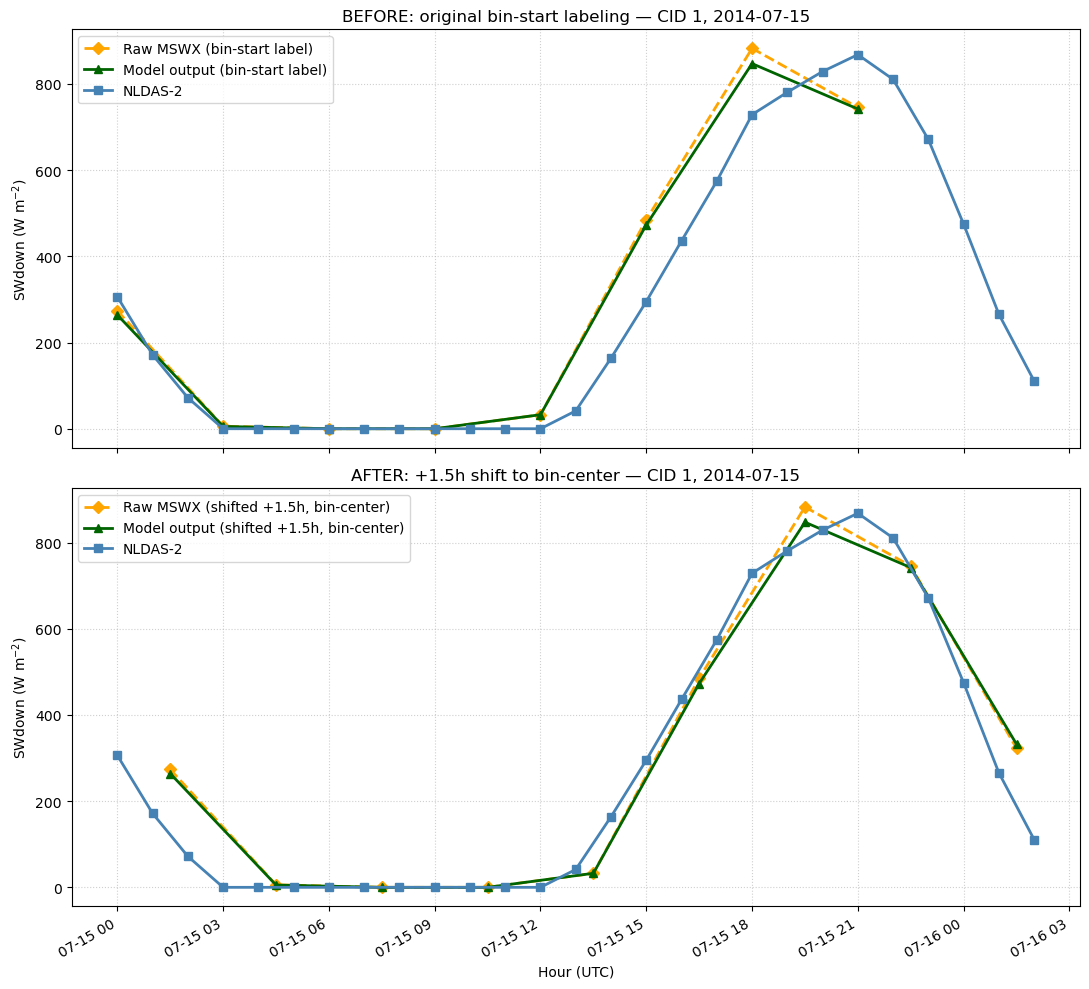

In [1]:
import netCDF4 as nc
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Paths
# ============================================================
EDIR_11YR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_100hru_full_domain_no_downscale"
CID = 1

output_path     = os.path.join(EDIR_11YR, "output_data", str(CID), "2014-01-01.nc")
swdown_raw_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/swdown.nc"

NLDAS_DIR = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/nldas_compare"

DAY = "2014-07-15"

CID1_LAT_MIN, CID1_LAT_MAX = 34.03055, 34.17283
CID1_LON_MIN, CID1_LON_MAX = -113.89591, -113.85827

# ============================================================
# 1. Model output forcing (swdn)
# ============================================================
with nc.Dataset(output_path) as ds:
    meta = ds.groups["metadata"]
    date_var = meta.variables["date"]
    output_dates = nc.num2date(date_var[:], units=date_var.units,
                                calendar=getattr(date_var, "calendar", "standard"),
                                only_use_cftime_datetimes=False, only_use_python_datetimes=True)
    output_dates = pd.DatetimeIndex(output_dates)
    swdn_out = ds.groups["data"].variables["swdn"][:]

swdn_out_mean = np.nanmean(swdn_out, axis=1)
series_output = pd.Series(swdn_out_mean, index=output_dates)

# ============================================================
# 2. Raw MSWX gridded source, subset to CID 1
# ============================================================
with nc.Dataset(swdown_raw_path) as ds:
    t_var = ds.variables["t"]
    raw_dates = pd.date_range("2014-01-01 00:00:00", periods=len(t_var), freq="3h")
    swdown_raw = np.ma.filled(ds.variables["swdown"][:], np.nan)
    lats = np.array(ds.variables["lat"][:])
    lons = np.array(ds.variables["lon"][:])

lat_mask = (lats >= CID1_LAT_MIN) & (lats <= CID1_LAT_MAX)
lon_mask = (lons >= CID1_LON_MIN) & (lons <= CID1_LON_MAX)

if lat_mask.sum() == 0 or lon_mask.sum() == 0:
    center_lat = (CID1_LAT_MIN + CID1_LAT_MAX) / 2
    center_lon = (CID1_LON_MIN + CID1_LON_MAX) / 2
    lat_idx = np.abs(lats - center_lat).argmin()
    lon_idx = np.abs(lons - center_lon).argmin()
    swdown_raw_mean = swdown_raw[:, lat_idx, lon_idx]
else:
    swdown_raw_subset = swdown_raw[:, lat_mask, :][:, :, lon_mask]
    swdown_raw_mean = np.nanmean(swdown_raw_subset, axis=(1, 2))

series_raw_mswx = pd.Series(swdown_raw_mean, index=raw_dates)

# ============================================================
# 3. NLDAS (hourly, unshifted -- treated as reference)
# ============================================================
ds_all = xr.open_mfdataset(os.path.join(NLDAS_DIR, "*.nc"), combine="by_coords")
center_lat = (CID1_LAT_MIN + CID1_LAT_MAX) / 2
center_lon = (CID1_LON_MIN + CID1_LON_MAX) / 2
ds_nearest = ds_all.sel(lat=center_lat, lon=center_lon, method="nearest")
swdown_nldas_da = ds_nearest["SWdown"].load()
series_nldas = swdown_nldas_da.to_series()

# ============================================================
# 4. Apply bin-center shift (+1.5h) to MSWX / model output
# ============================================================
series_raw_mswx_shifted = series_raw_mswx.copy()
series_raw_mswx_shifted.index = series_raw_mswx_shifted.index + pd.Timedelta(hours=1.5)

series_output_shifted = series_output.copy()
series_output_shifted.index = series_output_shifted.index + pd.Timedelta(hours=1.5)

# ============================================================
# 5. Restrict to the chosen day (use a slightly wider window so shifted points aren't cut off)
# ============================================================
window_start = f"{DAY} 00:00"
window_end   = pd.Timestamp(f"{DAY} 23:59") + pd.Timedelta(hours=3)

raw_mswx_day          = series_raw_mswx.loc[DAY]
output_day            = series_output.loc[DAY]
nldas_day             = series_nldas.loc[window_start:window_end]
raw_mswx_shifted_day   = series_raw_mswx_shifted.loc[window_start:window_end]
output_shifted_day     = series_output_shifted.loc[window_start:window_end]

# ============================================================
# 6. Plot: original (top) vs shifted (bottom)
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# --- Top: original, unshifted (bin-start labeling) ---
ax1.plot(raw_mswx_day.index, raw_mswx_day.values, color="orange", marker="D",
         linewidth=2, linestyle="--", label="Raw MSWX (bin-start label)")
ax1.plot(output_day.index, output_day.values, color="darkgreen", marker="^",
         linewidth=2, label="Model output (bin-start label)")
ax1.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
         linewidth=2, label="NLDAS-2")
ax1.set_title(f"BEFORE: original bin-start labeling — CID {CID}, {DAY}")
ax1.set_ylabel(r"SWdown (W m$^{-2}$)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# --- Bottom: shifted +1.5h (bin-center labeling) ---
ax2.plot(raw_mswx_shifted_day.index, raw_mswx_shifted_day.values, color="orange", marker="D",
         linewidth=2, linestyle="--", label="Raw MSWX (shifted +1.5h, bin-center)")
ax2.plot(output_shifted_day.index, output_shifted_day.values, color="darkgreen", marker="^",
         linewidth=2, label="Model output (shifted +1.5h, bin-center)")
ax2.plot(nldas_day.index, nldas_day.values, color="steelblue", marker="s",
         linewidth=2, label="NLDAS-2")
ax2.set_title(f"AFTER: +1.5h shift to bin-center — CID {CID}, {DAY}")
ax2.set_xlabel("Hour (UTC)")
ax2.set_ylabel(r"SWdown (W m$^{-2}$)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

fig.autofmt_xdate()
fig.tight_layout()

out_plot = f"/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/full_domain_output_plot/swdown_shift_comparison_cid{CID}_{DAY}.png"
os.makedirs(os.path.dirname(out_plot), exist_ok=True)
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {out_plot}")

# ============================================================
# 7. Report peak timing before/after
# ============================================================
print(f"\nOriginal peak times (bin-start label):")
print(f"  MSWX:   {raw_mswx_day.idxmax()}  ({raw_mswx_day.max():.1f} W/m2)")
print(f"  Model:  {output_day.idxmax()}  ({output_day.max():.1f} W/m2)")
print(f"  NLDAS:  {nldas_day.idxmax()}  ({nldas_day.max():.1f} W/m2)")

print(f"\nShifted peak times (bin-center label):")
print(f"  MSWX:   {raw_mswx_shifted_day.idxmax()}  ({raw_mswx_shifted_day.max():.1f} W/m2)")
print(f"  Model:  {output_shifted_day.idxmax()}  ({output_shifted_day.max():.1f} W/m2)")

plt.show()

In [3]:
import netCDF4 as nc
import json

metadata_file = "/home/battobrah@xsede.org/HydroBlocks_Enrico_dev/scriptpp_11yrs_100hru.json"  # <-- replace with your real path
metadata = json.load(open(metadata_file))
config_dt_seconds = metadata['dt']

print(f"Configured model dt: {config_dt_seconds} seconds ({config_dt_seconds/3600} hours)\n")

workspace = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1"

meteorology_vars = ['lwdown', 'swdown', 'tair', 'precip', 'psurf', 'wind', 'spfh']

for var in meteorology_vars:
    file_path = f"{workspace}/{var}.nc"
    try:
        fp = nc.Dataset(file_path)
        units_str = fp.variables['t'].units
        nc_step_minutes = int(60 * float(units_str.split(' ')[0].split('h')[0]))
        nc_step_seconds = nc_step_minutes * 60
        fp.close()

        match = "OK" if nc_step_seconds == config_dt_seconds else "MISMATCH"
        print(f"{var:10s} | units='{units_str}' | parsed step={nc_step_seconds}s | {match}")

    except Exception as e:
        print(f"{var:10s} | ERROR reading/parsing: {e}")

Configured model dt: 10800.0 seconds (3.0 hours)

lwdown     | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
swdown     | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
tair       | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
precip     | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
psurf      | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
wind       | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
spfh       | units='3hr since 2014-01-01 00:00:00.0' | parsed step=10800s | OK
